In [1]:
import sys
import os

# Add the parent directory to sys.path to allow imports from src
# This assumes the notebook is running in the 'notebooks' folder
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

from src.dataloader import get_pmi_matrix, get_batches, load_static_embeddings, init_random_embeddings
from src.utils import update_embeddings
from src.models import DynamicWord2Vec
from src.train import train
from src.vizz import plot_norm_trajectory, plot_tsne_trajectory, load_wordlist
import torch

## Configuration

Set up the parameters for the experiment. We use a simple class to simulate command-line arguments.

In [2]:
class Args:
    def __init__(self):
        self.nw = 20936  # Vocabulary size
        self.start_year = 1990
        self.end_year = 2015 # Reduced range for quick testing, set to 2015 for full run
        self.cuda = torch.cuda.is_available()
        
        # Paths are relative to the root of the workspace (parent of notebooks/)
        self.data_dir = '../data/data_train_model/wordPairPMI_' 
        self.save_dir = '../results/'
        self.static_file = '../data/data_other_embeddings/emb_static.mat'
        
        # Hyperparameters
        self.iters = 5
        self.lam = 10.0   # Frob regularizer
        self.gam = 100.0  # Forcing regularizer
        self.tau = 50.0   # Smoothing regularizer
        self.rank = 50
        self.batch_size = 10000 # Smaller batch size for interactive run, or use self.nw for full batch
        self.emph = 1.0

args = Args()
print(f"Running on device: {'cuda' if args.cuda else 'cpu'}")

Running on device: cpu


## Training

Run the training loop. This will save the model checkpoints to the `results` folder.

In [3]:
# Create results directory if it doesn't exist
if not os.path.exists(args.save_dir):
    os.makedirs(args.save_dir)

# Run training
# Note: This might take a while depending on the data size and hardware
try:
    train(args)
    print("Training complete!")
except FileNotFoundError as e:
    print(f"Error: {e}")
    print("Please ensure the data files are present in the '../data' directory.")

Using device: cpu
Initializing...



A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.0.2 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "c:\GitHub\LOCAL\Lib\site-packages\ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "c:\GitHub\LOCAL\Lib\site-packages\traitlets\config\application.py", line 1075, in launch_instance
    app.start()
  File "c:\GitHub\LOCAL\Lib\site-packages\ipykernel\kernelapp.py", line 739, in start
    self.io_loop.start()
  File "c:\GitHub\LOCAL\Lib\site-packages\tornado\platform\asyncio.py", l

Iteration 0
Iteration 0, Time 1990 (Index 0)
Data file ../data/data_train_model/wordPairPMI_0.csv not found. Skipping.
Iteration 0, Time 1991 (Index 1)
Data file ../data/data_train_model/wordPairPMI_1.csv not found. Skipping.
Iteration 0, Time 1992 (Index 2)
Data file ../data/data_train_model/wordPairPMI_2.csv not found. Skipping.
Iteration 0, Time 1993 (Index 3)
Data file ../data/data_train_model/wordPairPMI_3.csv not found. Skipping.
Iteration 0, Time 1994 (Index 4)
Data file ../data/data_train_model/wordPairPMI_4.csv not found. Skipping.
Iteration 0, Time 1995 (Index 5)
Data file ../data/data_train_model/wordPairPMI_5.csv not found. Skipping.
Iteration 0, Time 1996 (Index 6)
Data file ../data/data_train_model/wordPairPMI_6.csv not found. Skipping.
Iteration 0, Time 1997 (Index 7)
Data file ../data/data_train_model/wordPairPMI_7.csv not found. Skipping.
Iteration 0, Time 1998 (Index 8)
Data file ../data/data_train_model/wordPairPMI_8.csv not found. Skipping.
Iteration 0, Time 1999 (I

## Visualization

After training, we can visualize the results.

In [4]:
# Load the trained model from the last iteration
model = DynamicWord2Vec(args.nw, range(args.start_year, args.end_year + 1), args.rank, device='cpu')
save_file_prefix = f"L{args.lam}T{args.tau}G{args.gam}A{args.emph}"
load_path = os.path.join(args.save_dir, save_file_prefix)

# Load the last iteration
if model.load(load_path, args.iters - 1):
    print("Model loaded successfully.")
else:
    print("Could not load model. Ensure training finished successfully.")

Model loaded successfully.


In [9]:
# Load word list to map indices to words
wordlist_path = '../data/data_train_model/wordlist.txt' # Adjust path if necessary
wordlist, word2id = load_wordlist(wordlist_path)

if wordlist:
    print(f"Loaded {len(wordlist)} words.")
else:
    print("Wordlist not found. Creating dummy wordlist for demonstration.")
    # Create dummy mapping if file doesn't exist
    wordlist = [f"word_{i}" for i in range(args.nw)]
    word2id = {w: i for i, w in enumerate(wordlist)}

Loaded 20000 words.


### Word Norm Trajectories
Visualize how the "significance" (norm) of words changes over time.

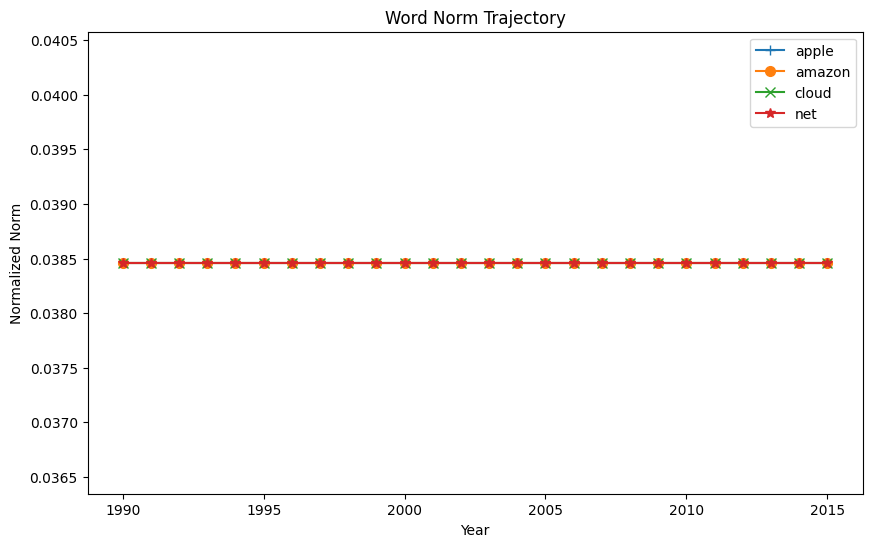

In [10]:
# Select words to visualize
# Replace these with words relevant to your dataset
target_words = ['apple', 'amazon', 'cloud', 'net'] 
valid_words = [w for w in target_words if w in word2id]

if valid_words:
    plot_norm_trajectory(model.U, valid_words, word2id, model.time_points)
else:
    print("None of the target words found in vocabulary.")

### t-SNE Trajectory
Visualize the semantic shift of a specific word in 2D space.

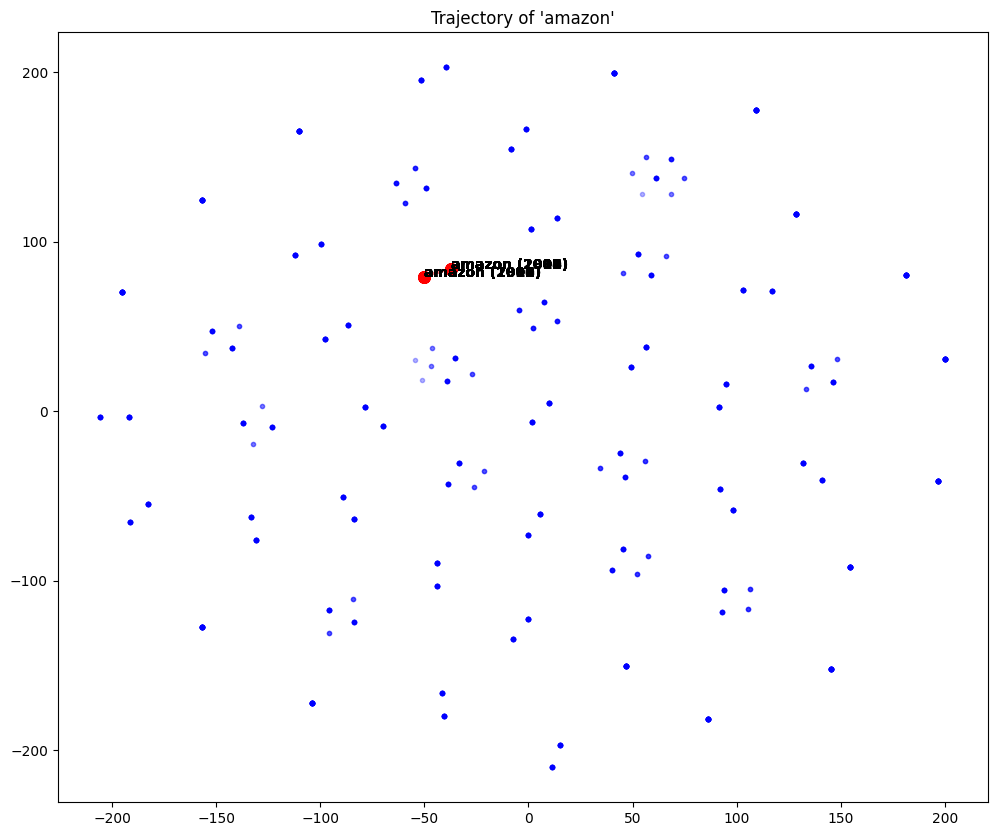

In [11]:
target_word = 'amazon'

if target_word in word2id:
    plot_tsne_trajectory(model.U, target_word, word2id, wordlist, model.time_points)
else:
    print(f"Word '{target_word}' not found in vocabulary.")